## Step 3 — Preprocessing pipeline ✅

#### Goal: Prepare clean, fixed-size, normalized image data for model training.

#### Your proposal says preprocessing should include: verifying temporal order and metadata, standardizing image sizes and resolutions, applying normalization, handling missing/corrupted frames, and preparing fixed train/validation/test splits

In [2]:
from pathlib import Path
import pandas as pd
from PIL import Image
from tqdm import tqdm
import json
import numpy as np

In [3]:
RAW_DATA_DIR = Path("../data/raw/DAFA-LS")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_IMAGE_DIR = Path("../data/processed_images")

METADATA_PATH = PROCESSED_DIR / "metadata.csv"

PROCESSED_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
metadata_df = pd.read_csv(METADATA_PATH)

print(metadata_df.head())
print("Total frames:", len(metadata_df))
print("Total sites:", metadata_df["site_id"].nunique())

   split  site_id class_name  label  frame_index   frame_name  \
0  train        1     looted      1            0  2016_01.jpg   
1  train        1     looted      1            1  2016_02.jpg   
2  train        1     looted      1            2  2016_03.jpg   
3  train        1     looted      1            3  2016_04.jpg   
4  train        1     looted      1            4  2016_05.jpg   

                                 frame_path  
0  ..\data\raw\DAFA_LS\looted\1\2016_01.jpg  
1  ..\data\raw\DAFA_LS\looted\1\2016_02.jpg  
2  ..\data\raw\DAFA_LS\looted\1\2016_03.jpg  
3  ..\data\raw\DAFA_LS\looted\1\2016_04.jpg  
4  ..\data\raw\DAFA_LS\looted\1\2016_05.jpg  
Total frames: 64114
Total sites: 540


In [5]:
IMAGE_SIZE = (224, 224)

### Create preprocessing function

In [6]:
def preprocess_image(input_path, output_path, image_size=(224, 224)):
    """
    Opens an image, converts to RGB, resizes it, and saves it.
    """
    input_path = Path(input_path)
    output_path = Path(output_path)

    output_path.parent.mkdir(parents=True, exist_ok=True)

    img = Image.open(input_path).convert("RGB")
    img = img.resize(image_size)

    img.save(output_path)
    

In [7]:
processed_records = []
failed_images = []

for _, row in tqdm(metadata_df.iterrows(), total=len(metadata_df)):
    input_path = Path(row["frame_path"])

    class_name = row["class_name"]
    site_id = str(row["site_id"])
    frame_name = row["frame_name"]

    output_path = PROCESSED_IMAGE_DIR / class_name / site_id / frame_name

    try:
        preprocess_image(
            input_path=input_path,
            output_path=output_path,
            image_size=IMAGE_SIZE
        )

        processed_records.append({
            "split": row["split"],
            "site_id": site_id,
            "class_name": class_name,
            "label": row["label"],
            "frame_index": row["frame_index"],
            "frame_name": frame_name,
            "raw_frame_path": str(input_path),
            "processed_frame_path": str(output_path)
        })

    except Exception as e:
        failed_images.append({
            "split": row["split"],
            "site_id": site_id,
            "class_name": class_name,
            "label": row["label"],
            "frame_name": frame_name,
            "raw_frame_path": str(input_path),
            "error": str(e)
        })

100%|██████████| 64114/64114 [13:29<00:00, 79.20it/s] 


In [8]:
processed_metadata_df = pd.DataFrame(processed_records)
failed_images_df = pd.DataFrame(failed_images)

processed_metadata_df.to_csv(PROCESSED_DIR / "processed_metadata.csv", index=False)
failed_images_df.to_csv(PROCESSED_DIR / "failed_preprocessing_images.csv", index=False)

print("Successfully processed:", len(processed_metadata_df))
print("Failed:", len(failed_images_df))

Successfully processed: 64114
Failed: 0


In [9]:
check_info = []

for _, row in tqdm(processed_metadata_df.iterrows(), total=len(processed_metadata_df)):
    img_path = Path(row["processed_frame_path"])

    try:
        img = Image.open(img_path)
        width, height = img.size
        mode = img.mode

        check_info.append({
            "processed_frame_path": str(img_path),
            "width": width,
            "height": height,
            "mode": mode
        })

    except Exception as e:
        check_info.append({
            "processed_frame_path": str(img_path),
            "width": None,
            "height": None,
            "mode": None,
            "error": str(e)
        })

processed_image_check_df = pd.DataFrame(check_info)

print(processed_image_check_df[["width", "height", "mode"]].value_counts())

100%|██████████| 64114/64114 [08:52<00:00, 120.47it/s]


width  height  mode
224    224     RGB     64114
Name: count, dtype: int64


In [10]:
processed_image_check_df.to_csv(PROCESSED_DIR / "processed_image_check.csv", index=False)

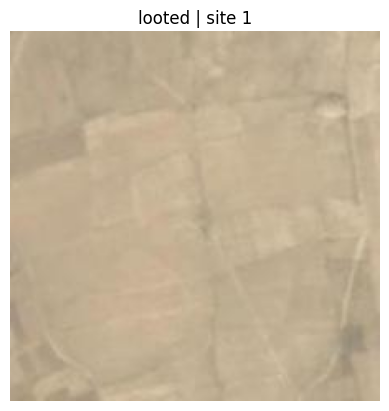

In [11]:
import matplotlib.pyplot as plt

sample = processed_metadata_df.iloc[0]
img = Image.open(sample["processed_frame_path"]).convert("RGB")

plt.imshow(img)
plt.title(sample["class_name"] + " | site " + str(sample["site_id"]))
plt.axis("off")
plt.show()

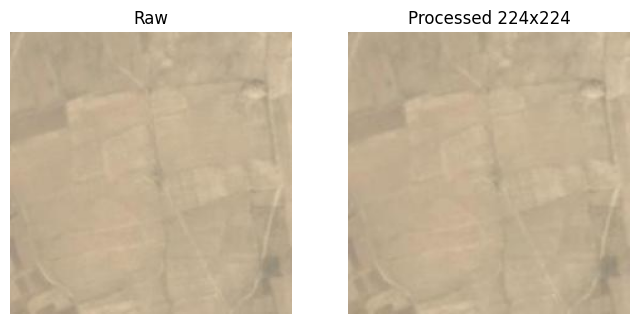

In [12]:
sample = processed_metadata_df.iloc[0]

raw_img = Image.open(sample["raw_frame_path"]).convert("RGB")
processed_img = Image.open(sample["processed_frame_path"]).convert("RGB")

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title("Raw")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_img)
plt.title("Processed 224x224")
plt.axis("off")

plt.show()

In [13]:
train_df = processed_metadata_df[processed_metadata_df["split"] == "train"]

print("Training frames:", len(train_df))

Training frames: 49736


### Calculate normalization mean and standard deviation

In [14]:
sum_channels = np.zeros(3)
sum_squared_channels = np.zeros(3)
num_pixels = 0

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    img = Image.open(row["processed_frame_path"]).convert("RGB")
    img_array = np.array(img).astype(np.float32) / 255.0

    # shape: H, W, C
    sum_channels += img_array.sum(axis=(0, 1))
    sum_squared_channels += (img_array ** 2).sum(axis=(0, 1))
    num_pixels += img_array.shape[0] * img_array.shape[1]

mean = sum_channels / num_pixels
std = np.sqrt((sum_squared_channels / num_pixels) - (mean ** 2))

print("Mean:", mean)
print("Std:", std)

100%|██████████| 49736/49736 [08:27<00:00, 97.99it/s] 

Mean: [0.66412494 0.57462657 0.42835551]
Std: [0.1793586  0.16803832 0.17305869]


In [15]:
normalization_stats = {
    "image_size": IMAGE_SIZE,
    "mean": mean.tolist(),
    "std": std.tolist()
}

with open(PROCESSED_DIR / "normalization_stats.json", "w") as f:
    json.dump(normalization_stats, f, indent=4)

In [18]:
from torchvision import transforms

In [19]:
transforms.Normalize(mean=mean, std=std)

Normalize(mean=[0.66412494 0.57462657 0.42835551], std=[0.1793586  0.16803832 0.17305869])